## Column Name	Description
#### InvoiceNo:
 A unique identifier for each sales transaction (invoice).
#### StockCode:	
The code representing the product stock-keeping unit (SKU).
#### Description:	
A brief description of the product.
#### Quantity
The number of units of the product sold in the transaction.
#### InvoiceDate
The date and time when the sale was recorded.
#### UnitPrice
The price per unit of the product in the transaction currency.
#### CustomerID
A unique identifier for each customer.
#### Country	
The customer's country.
#### Discount	
The discount applied to the transaction, if any.
#### PaymentMethod
The method of payment used for the transaction (e.g., PayPal, Bank Transfer).
#### ShippingCost
The cost of shipping for the transaction.
#### Category	
The category to which the product belongs (e.g., Electronics, Apparel).
#### SalesChannel	
The channel through which the sale was made (e.g., Online, In-store).
#### eturnStatus	
Indicates whether the item was returned or not.
#### ShipmentProvider	
The provider responsible for delivering the order (e.g., UPS, FedEx).
#### WarehouseLocation	
The warehouse location from which the order was fulfilled.
#### OrderPriority	
The priority level of the order (e.g., High, Medium, Low).

In [263]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#Lo primero que nos interesá es conocer parte de la estructura básica de nuestra info
df=pd.read_csv("online_sales_dataset.csv")
#columnas que tengo y filas
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Discount,PaymentMethod,ShippingCost,Category,SalesChannel,ReturnStatus,ShipmentProvider,WarehouseLocation,OrderPriority
0,221958,SKU_1964,White Mug,38,01/01/2020 00:00,1.71,37039.0,Australia,0.470000,Bank Transfer,10.79,Apparel,In-store,Not Returned,UPS,London,Medium
1,771155,SKU_1241,White Mug,18,01/01/2020 01:00,41.25,19144.0,Spain,0.190000,paypall,9.51,Electronics,Online,Not Returned,UPS,Rome,Medium
2,231932,SKU_1501,Headphones,49,01/01/2020 02:00,29.11,50472.0,Germany,0.350000,Bank Transfer,23.03,Electronics,Online,Returned,UPS,Berlin,High
3,465838,SKU_1760,Desk Lamp,14,01/01/2020 03:00,76.68,96586.0,Netherlands,0.140000,paypall,11.08,Accessories,Online,Not Returned,Royal Mail,Rome,Low
4,359178,SKU_1386,USB Cable,-30,01/01/2020 04:00,-68.11,NaN,United Kingdom,1.501433,Bank Transfer,NaN,Electronics,In-store,Not Returned,FedEx,NaN,Medium


In [264]:
#tipos de datos y faltantes 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49782 entries, 0 to 49781
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   InvoiceNo          49782 non-null  int64  
 1   StockCode          49782 non-null  object 
 2   Description        49782 non-null  object 
 3   Quantity           49782 non-null  int64  
 4   InvoiceDate        49782 non-null  object 
 5   UnitPrice          49782 non-null  float64
 6   CustomerID         44804 non-null  float64
 7   Country            49782 non-null  object 
 8   Discount           49782 non-null  float64
 9   PaymentMethod      49782 non-null  object 
 10  ShippingCost       47293 non-null  float64
 11  Category           49782 non-null  object 
 12  SalesChannel       49782 non-null  object 
 13  ReturnStatus       49782 non-null  object 
 14  ShipmentProvider   49782 non-null  object 
 15  WarehouseLocation  46297 non-null  object 
 16  OrderPriority      497

In [265]:
#estadísticos de las variables numéricas
df.describe()

,InvoiceNo,Quantity,UnitPrice,CustomerID,Discount,ShippingCost
count,49782.000000,49782.000000,49782.000000,44804.000000,49782.000000,47293.000000
mean,550681.239946,22.372343,47.537862,55032.871775,0.275748,17.494529
std,260703.009944,17.917774,33.479510,25913.660157,0.230077,7.220557
min,100005.000000,-50.000000,-99.980000,10001.000000,0.000000,5.000000
25%,324543.000000,11.000000,23.592500,32750.750000,0.130000,11.220000
50%,552244.000000,23.000000,48.920000,55165.000000,0.260000,17.500000
75%,776364.000000,37.000000,74.610000,77306.250000,0.380000,23.720000
max,999997.000000,49.000000,100.000000,99998.000000,1.999764,30.000000


In [266]:
df.shape

(49782, 17)

In [267]:
df.isnull().sum()

InvoiceNo               0
StockCode               0
Description             0
Quantity                0
InvoiceDate             0
UnitPrice               0
CustomerID           4978
Country                 0
Discount                0
PaymentMethod           0
ShippingCost         2489
Category                0
SalesChannel            0
ReturnStatus            0
ShipmentProvider        0
WarehouseLocation    3485
OrderPriority           0
dtype: int64

# Numéricas 

# Empezaré a hacer boxplots e histogramas para cada variable y así poder saber como tratarla

    VARIABLE OBJETIVO "Quantity"

In [268]:
df["Quantity"].isnull().sum()

np.int64(0)

Text(0.5, 1.0, 'Distribución de la variable objetivo')

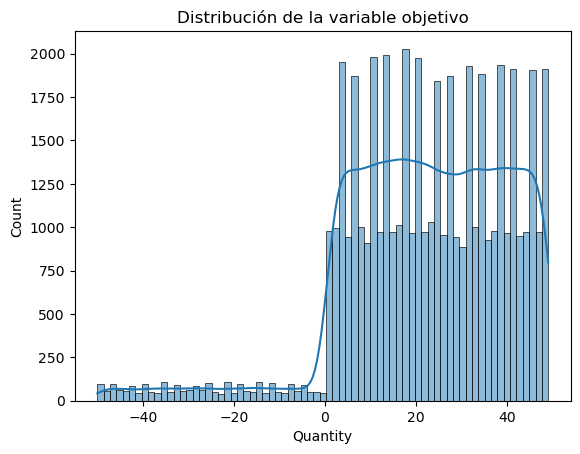

In [269]:
sns.histplot(df["Quantity"], kde=True)
plt.title("Distribución de la variable objetivo")

<Axes: ylabel='Quantity'>

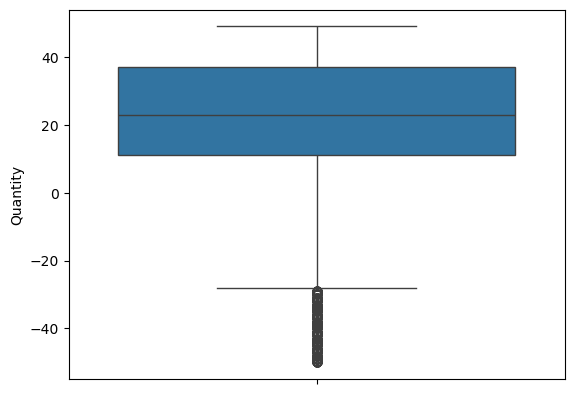

In [270]:
sns.boxplot(df["Quantity"])


In [271]:
#Hago un conteo de las negativas ya que me preocupa esto tanto como outliers como en distribución
df[df["Quantity"] < 0]["Quantity"].count()

np.int64(2489)

In [272]:
df = df.drop(df[df["Quantity"] < 0].index)


In [273]:
#vuelvo a revisar si ya no hay negativos, y vuelvo a checar distibuciones
df[df["Quantity"] < 0]["Quantity"].count()

np.int64(0)

Text(0.5, 1.0, 'Distribución de la variable objetivo')

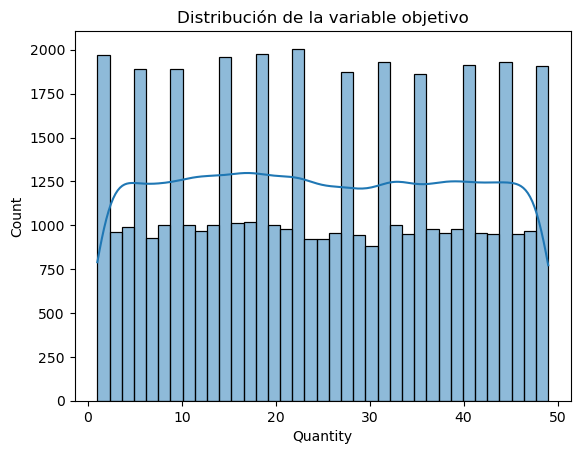

In [274]:
sns.histplot(df["Quantity"], kde=True)
plt.title("Distribución de la variable objetivo")

<Axes: ylabel='Quantity'>

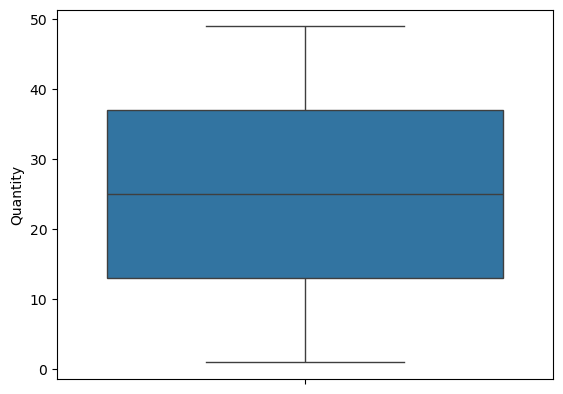

In [275]:
sns.boxplot(df["Quantity"])


    SOLUCIONADO


    VARIABLE "UnitPrice"

In [276]:
df["UnitPrice"].isnull().sum()

np.int64(0)

Text(0.5, 1.0, 'Distribución del Precio por Unidad ')

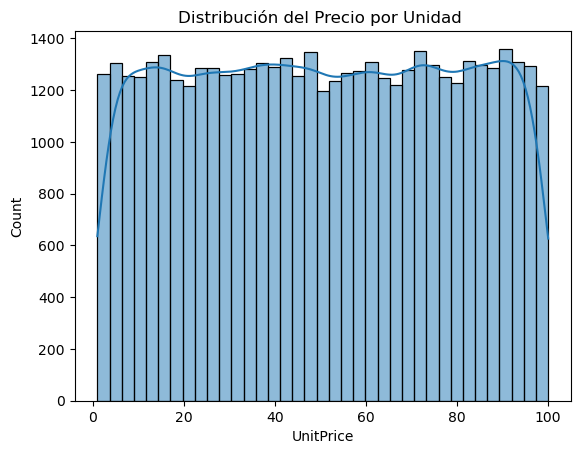

In [277]:
sns.histplot(df["UnitPrice"], kde=True)
plt.title("Distribución del Precio por Unidad ")

<Axes: ylabel='UnitPrice'>

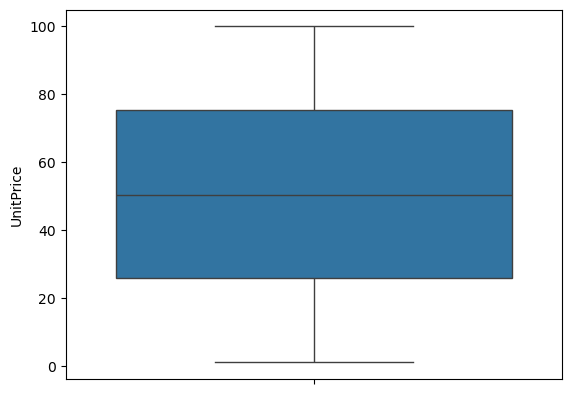

In [278]:
sns.boxplot(df["UnitPrice"])

    VARIEABLE "CoustomerID"

In [279]:
df["CustomerID"] = df["CustomerID"].fillna("Desconocido")

In [280]:
df["CustomerID"].value_counts()

CustomerID
Desconocido    2489
53125.0           6
16215.0           5
14461.0           5
91749.0           5
               ... 
36515.0           1
63980.0           1
85250.0           1
12024.0           1
13030.0           1
Name: count, Length: 35390, dtype: int64

    VARIABLE "Discount"

In [281]:
df["Discount"].isnull().sum()

np.int64(0)

Text(0.5, 1.0, 'Distribución de la variable Discount')

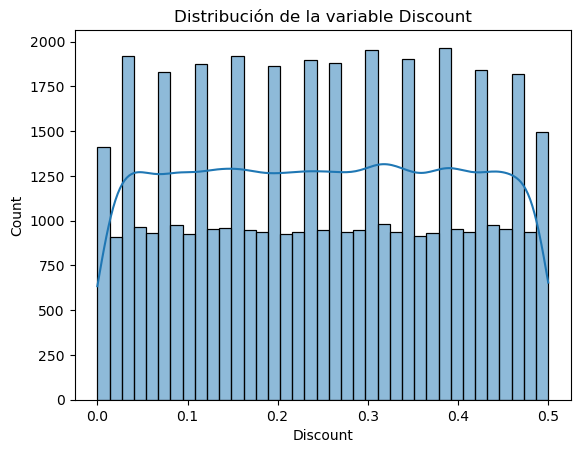

In [282]:
sns.histplot(df["Discount"],kde=True)
plt.title("Distribución de la variable Discount")

<Axes: ylabel='Discount'>

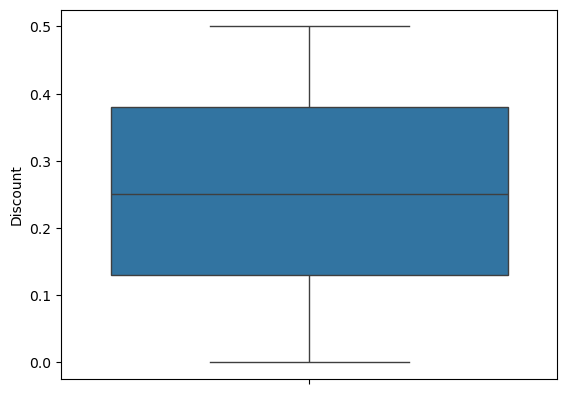

In [283]:
sns.boxplot(df["Discount"])

In [284]:
df["Discount"].value_counts()

Discount
0.31    1057
0.34    1012
0.39    1003
0.49    1000
0.32     982
0.44     977
0.09     975
0.16     970
0.05     967
0.03     967
0.23     963
0.38     963
0.14     961
0.08     956
0.12     955
0.45     955
0.13     955
0.20     954
0.26     952
0.04     952
0.40     951
0.29     950
0.15     948
0.17     948
0.25     948
0.22     937
0.18     936
0.33     936
0.41     935
0.48     935
0.28     934
0.46     934
0.24     932
0.37     932
0.27     930
0.06     929
0.43     929
0.21     928
0.01     926
0.10     923
0.11     920
0.36     915
0.42     913
0.19     912
0.02     911
0.30     895
0.35     890
0.47     887
0.07     874
0.50     493
0.00     486
Name: count, dtype: int64

In [285]:
df["ShippingCost"].isnull().sum()

np.int64(0)

Text(0.5, 1.0, 'Distribución de ShippingCoast')

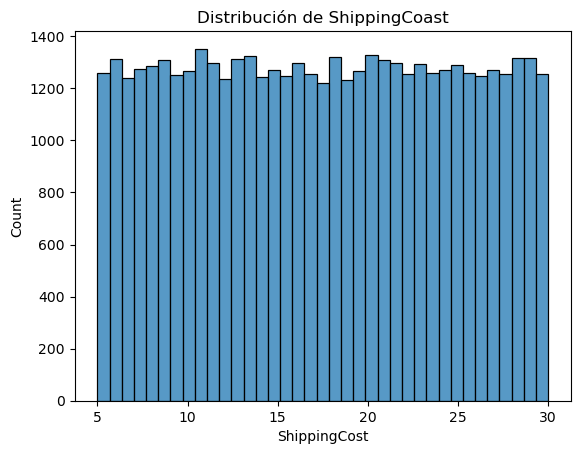

In [286]:
sns.histplot(df["ShippingCost"])
plt.title("Distribución de ShippingCoast")

<Axes: ylabel='ShippingCost'>

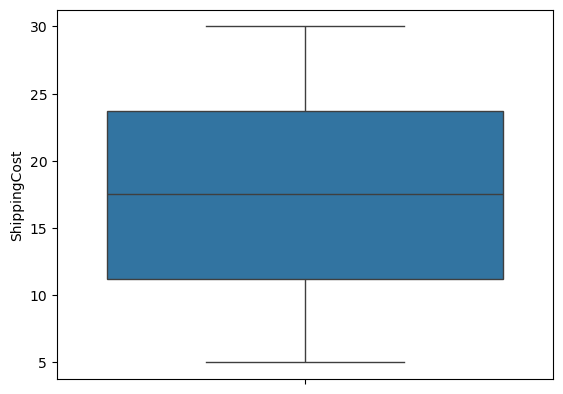

In [287]:
sns.boxplot(df["ShippingCost"])

# Categóricas

    VARIABLE Country

In [288]:
df["Country"].isnull().sum()

np.int64(0)

In [289]:
df["Country"].value_counts()


Country
France            4021
Sweden            3994
United Kingdom    3973
Germany           3972
Belgium           3963
Portugal          3959
Netherlands       3957
Norway            3938
Spain             3897
Australia         3894
United States     3880
Italy             3845
Name: count, dtype: int64

    VARIABLE PaymentMethod

In [290]:
df["PaymentMethod"].isnull().sum()

np.int64(0)

In [291]:
df["PaymentMethod"].value_counts()

PaymentMethod
Bank Transfer    15933
Credit Card      15721
paypall          15639
Name: count, dtype: int64

    VARIABLE Category

In [292]:
df["Category"].isnull().sum()

np.int64(0)

In [293]:
df["Category"].value_counts()

Category
Furniture      9577
Accessories    9454
Stationery     9446
Electronics    9433
Apparel        9383
Name: count, dtype: int64

    VARIABLE OrderPriority

In [294]:
df["OrderPriority"].isnull().sum()

np.int64(0)

In [295]:
df["OrderPriority"].value_counts()

OrderPriority
Medium    15822
High      15763
Low       15708
Name: count, dtype: int64

    VARIABLE Description

In [296]:
df["Description"].isnull().sum()

np.int64(0)

In [297]:
df["Description"].value_counts()

Description
Wall Clock        4362
USB Cable         4359
Backpack          4355
Desk Lamp         4338
White Mug         4318
Office Chair      4301
Headphones        4282
T-shirt           4268
Blue Pen          4264
Notebook          4230
Wireless Mouse    4216
Name: count, dtype: int64

    VARIABLE Sales Channel

In [298]:
df["SalesChannel"].isnull().sum()

np.int64(0)

In [299]:
df["SalesChannel"].value_counts()

SalesChannel
Online      23762
In-store    23531
Name: count, dtype: int64

    VARIABLE ReturnStatus

In [300]:
df["ReturnStatus"].isnull().sum()

np.int64(0)

In [301]:
df["ReturnStatus"].value_counts()

ReturnStatus
Not Returned    42647
Returned         4646
Name: count, dtype: int64

    VARIABLE ShipmentProvider

In [302]:
df["ShipmentProvider"].isnull().sum()

np.int64(0)

In [303]:
df["ShipmentProvider"].value_counts()

ShipmentProvider
FedEx         11902
Royal Mail    11816
DHL           11796
UPS           11779
Name: count, dtype: int64

    VARIABLE WarehouseLocation

In [304]:
df["WarehouseLocation"].isnull().sum()

np.int64(996)

In [305]:
df["WarehouseLocation"].value_counts()

WarehouseLocation
Amsterdam    9458
London       9230
Rome         9226
Berlin       9210
Paris        9173
Name: count, dtype: int64

In [306]:
df["WarehouseLocation"] = df["WarehouseLocation"].fillna("Desconocido")

In [307]:
df["WarehouseLocation"].value_counts()

WarehouseLocation
Amsterdam      9458
London         9230
Rome           9226
Berlin         9210
Paris          9173
Desconocido     996
Name: count, dtype: int64

## Transformación general
Luego de revisar una por una, podemos validar la decisión de transformarlas a one hot encoding (la cantidad de categorías es suficiente), por lo que podemos aplicarle el one hot.

In [308]:
cat_cols = ["PaymentMethod", "SalesChannel", "Category", "ReturnStatus",
            "ShipmentProvider", "WarehouseLocation", "OrderPriority", "Country","Description"]

df_encoded = pd.get_dummies(df, columns=cat_cols)

In [309]:

df_encoded.head(10)

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Discount,ShippingCost,PaymentMethod_Bank Transfer,PaymentMethod_Credit Card,...,Description_Blue Pen,Description_Desk Lamp,Description_Headphones,Description_Notebook,Description_Office Chair,Description_T-shirt,Description_USB Cable,Description_Wall Clock,Description_White Mug,Description_Wireless Mouse
0,221958,SKU_1964,38,01/01/2020 00:00,1.71,37039.0,0.47,10.79,True,False,...,False,False,False,False,False,False,False,False,True,False
1,771155,SKU_1241,18,01/01/2020 01:00,41.25,19144.0,0.19,9.51,False,False,...,False,False,False,False,False,False,False,False,True,False
2,231932,SKU_1501,49,01/01/2020 02:00,29.11,50472.0,0.35,23.03,True,False,...,False,False,True,False,False,False,False,False,False,False
3,465838,SKU_1760,14,01/01/2020 03:00,76.68,96586.0,0.14,11.08,False,False,...,False,True,False,False,False,False,False,False,False,False
5,744167,SKU_1006,47,01/01/2020 05:00,70.16,53887.0,0.48,13.98,False,True,...,False,False,False,False,True,False,False,False,False,False
6,210268,SKU_1087,25,01/01/2020 06:00,85.74,46567.0,0.15,12.92,True,False,...,False,False,False,False,False,False,True,False,False,False
7,832180,SKU_1597,8,01/01/2020 07:00,95.65,75098.0,0.04,6.48,True,False,...,False,False,False,True,False,False,False,False,False,False
8,154886,SKU_1907,19,01/01/2020 08:00,98.19,87950.0,0.05,12.56,False,False,...,False,False,False,False,False,False,False,False,False,True
9,237337,SKU_1866,40,01/01/2020 09:00,98.17,39718.0,0.16,7.71,True,False,...,False,False,True,False,False,False,False,False,False,False
10,621430,SKU_1144,49,01/01/2020 10:00,87.56,13030.0,0.19,9.83,False,False,...,False,False,False,True,False,False,False,False,False,False


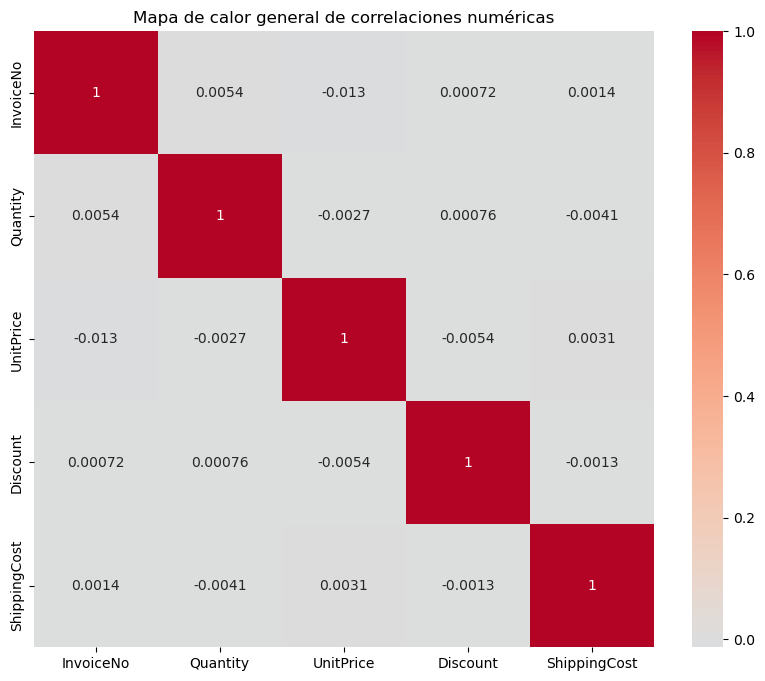

In [310]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar solo columnas numéricas
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Mapa de calor general de correlaciones numéricas")
plt.show()


# PARTE 2 DEL PROYECTO + CORRECCIÓN

# Corrección:
    *Haré una variable nueva llamada TotalSales=Quantity×UnitPrice
    *Nivel mensual
    *Agruparé por sku+ fecha

In [311]:
df['TotalSales'] = df['Quantity'] * df['UnitPrice']

In [312]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
df['month'] = df['InvoiceDate'].dt.to_period('M').dt.to_timestamp()

In [313]:
monthly = df.groupby(['StockCode', 'month']).agg({
    'Quantity': 'sum',
    'UnitPrice': 'mean',
    'TotalSales': 'sum'
}).reset_index()
monthly

,StockCode,month,Quantity,UnitPrice,TotalSales
0,SKU_1000,2020-01-01,21,1.07,22.47
1,SKU_1000,2020-04-01,43,60.66,2608.38
2,SKU_1000,2020-05-01,33,71.34,2354.22
3,SKU_1000,2020-07-01,30,38.20,1146.00
4,SKU_1000,2021-06-01,12,69.40,832.80
...,...,...,...,...,...
16445,SKU_1999,2023-01-01,31,16.30,505.30
16446,SKU_1999,2023-02-01,1,65.83,65.83
16447,SKU_1999,2023-03-01,8,65.00,520.00
16448,SKU_1999,2023-06-01,14,32.40,453.60


    Crearé features que me ayuden al momento de pasarlo a mi modelo

In [314]:
#lags
monthly['sales_lag_1'] = monthly.groupby('StockCode')['TotalSales'].shift(1)
monthly['sales_lag_2'] = monthly.groupby('StockCode')['TotalSales'].shift(2)
monthly['sales_lag_3'] = monthly.groupby('StockCode')['TotalSales'].shift(3)


In [315]:
#rolling windows para ver los promedios moviles y capturar tendencías.(nos ayudan a capturar las estacionalidades)
monthly['rolling_3'] = (
    monthly.groupby('StockCode')['TotalSales']
           .rolling(3)
           .mean()
           .reset_index(0, drop=True)
)

In [316]:
monthly['year'] = monthly['month'].dt.year
monthly['month_num'] = monthly['month'].dt.month
monthly['quarter'] = monthly['month'].dt.quarter

    El siguiente paso va a ser ordenar las fechas y eliminar nulos que pudieron generarse con el lag o los rolling.

In [317]:
monthly = monthly.sort_values(['StockCode', 'month'])

In [318]:
df_model = monthly.dropna().reset_index(drop=True)

In [319]:
pip install category_encoders

Note: you may need to restart the kernel to use updated packages.


In [320]:
y = df_model['TotalSales']
X = df_model.drop(['TotalSales', 'month'], axis=1)

print(X.columns)  


Index(['StockCode', 'Quantity', 'UnitPrice', 'sales_lag_1', 'sales_lag_2',
       'sales_lag_3', 'rolling_3', 'year', 'month_num', 'quarter'],
      dtype='object')


In [321]:
split_date = pd.to_datetime('2025-04-01')  

train_mask = df_model['month'] < split_date
test_mask  = df_model['month'] >= split_date

X_train = X[train_mask].copy()
y_train = y[train_mask].copy()

X_test  = X[test_mask].copy()
y_test  = y[test_mask].copy()

print("Tamaño train:", len(X_train), " | Tamaño test:", len(X_test))


Tamaño train: 11922  | Tamaño test: 1528


In [322]:
enc = TargetEncoder(cols=['StockCode'])


X_train_enc = enc.fit_transform(X_train, y_train)  
X_test_enc  = enc.transform(X_test)               


    Haré una prueba para el modelo RandomForest

In [323]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_enc, y_train)

RandomForestRegressor(max_depth=12, n_estimators=300, n_jobs=-1,
                      random_state=42)

In [324]:
X_train_enc

,StockCode,Quantity,UnitPrice,sales_lag_1,sales_lag_2,sales_lag_3,rolling_3,year,month_num,quarter
0,1328.518314,30,38.20,2354.22,2608.38,22.47,2036.200000,2020,7,3
1,1328.518314,12,69.40,1146.00,2354.22,2608.38,1444.340000,2021,6,2
2,1328.518314,25,87.16,832.80,1146.00,2354.22,1385.933333,2021,7,3
3,1328.518314,36,17.34,2179.00,832.80,1146.00,1212.013333,2023,1,1
4,1328.518314,4,56.85,624.24,2179.00,832.80,1010.213333,2023,4,2
...,...,...,...,...,...,...,...,...,...,...
13445,1346.322572,31,16.30,1103.35,3775.82,1738.57,1794.823333,2023,1,1
13446,1346.322572,1,65.83,505.30,1103.35,3775.82,558.160000,2023,2,1
13447,1346.322572,8,65.00,65.83,505.30,1103.35,363.710000,2023,3,1
13448,1346.322572,14,32.40,520.00,65.83,505.30,346.476667,2023,6,2


X_train_enc

In [325]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred = model.predict(X_test_enc)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

mape = (abs((y_test - y_pred) / y_test).mean()) * 100

print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"MAPE: {mape:,.2f}%")

MAE:  40.17
RMSE: 125.23
MAPE: 3.08%


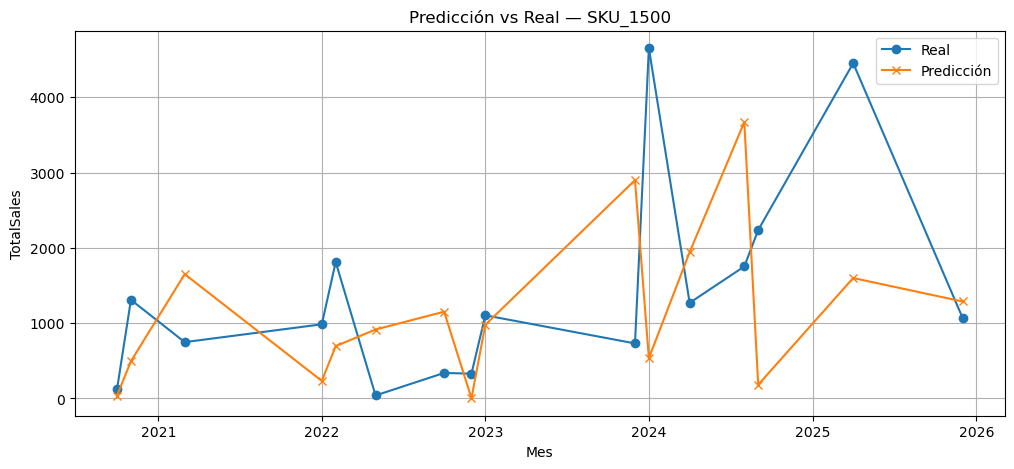

In [326]:
import matplotlib.pyplot as plt
import pandas as pd


sku = 'SKU_1500'


X_full_enc = pd.concat([X_train_enc, X_test_enc], axis=0)

full_pred = model.predict(X_full_enc)

df_pred = df_model.copy()
df_pred['pred'] = full_pred

sku_data = df_pred[df_pred['StockCode'] == sku]

plt.figure(figsize=(12,5))
plt.plot(sku_data['month'], sku_data['TotalSales'], label='Real', marker='o')
plt.plot(sku_data['month'], sku_data['pred'], label='Predicción', marker='x')
plt.title(f'Predicción vs Real — {sku}')
plt.xlabel('Mes')
plt.ylabel('TotalSales')
plt.grid(True)
plt.legend()
plt.show()


A pesar de sus buenos resultados quiero probar tunearlo

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

# mdelo base
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

#parametros
param_dist = {
    'n_estimators': [200, 300, 500, 700, 1000],
    'max_depth': [5, 8, 10, 12, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['auto', 'sqrt', 0.3, 0.5, 0.7],
    'bootstrap': [True, False]
}

# busqueda randomizada
rf_tuner = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,                     # aver que show con 20
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

rf_tuner.fit(X_train_enc, y_train)

best_rf = rf_tuner.best_estimator_

print("\nMejores parámetros encontrados:")
print(rf_tuner.best_params_)

# predictt
rf_tuned_pred = best_rf.predict(X_test_enc)

# errores
print_metrics(y_test, rf_tuned_pred, "RandomForest Tuned")


Fitting 3 folds for each of 20 candidates, totalling 60 fits


d:\programas\Anaconda\anaconda\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
15 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
7 fits failed with the following error:
Traceback (most recent call last):
  File "d:\programas\Anaconda\anaconda\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\programas\Anaconda\anaconda\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "d:\programas\Anaconda\anaconda\Lib\site-packages\sklearn\base.py", line 436, i


Mejores parámetros encontrados:
{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 8, 'max_features': 0.7, 'max_depth': None, 'bootstrap': True}

Modelo: RandomForest Tuned
  MAE:  42.60
  RMSE: 125.04
  MAPE: 5.17%


## MEJOR NADA JAJAJJAJA(USARÉ EL NO TUNEADO)

    Ahora probaré un XGBoost

In [327]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [328]:
#haré una función para solo llamarla cuando necesite revisar los resultados del mae, mape y rmse

def print_metrics(y_true, y_pred, nombre_modelo):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\nModelo: {nombre_modelo}")
    print(f"  MAE:  {mae:,.2f}")
    print(f"  RMSE: {rmse:,.2f}")
    print(f"  MAPE: {mape:,.2f}%")


In [329]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train_enc, y_train)

xgb_pred = xgb_model.predict(X_test_enc)

print_metrics(y_test, xgb_pred, "XGBoost")




Modelo: XGBoost
  MAE:  45.59
  RMSE: 98.58
  MAPE: 8.01%


In [330]:
#no me convencen los resultados así que tuneamos
from sklearn.model_selection import TimeSeriesSplit
#defino el timeseriessplit
tscv = TimeSeriesSplit(n_splits=5)

In [331]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    tree_method='hist'  
)


In [332]:
param_grid = {
    'n_estimators': [300, 500, 700, 900],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6, 8],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3, 1],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [1, 1.5, 2]
}


In [333]:
from sklearn.model_selection import RandomizedSearchCV

xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=25,                # puedes aumentar si quieres más calidad
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    cv=tscv,
    verbose=2,
    random_state=42
)

xgb_search.fit(X_train_enc, y_train)


Fitting 5 folds for each of 25 candidates, totalling 125 fits


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamm...
                                          num_parallel_tree=None, ...),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'gamma': [0, 0.1, 0.3, 1],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [3, 4, 5, 6, 8],
                                        'n_estimators': [300, 500, 700, 900],
                                        'reg_alpha': [0, 0.1, 0.5],
                                        'reg_lambda': [1, 1.5, 2],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='neg_mean_absolute_error',
                   verbose=2)

In [334]:
best_xgb = xgb_search.best_estimator_

print("Mejores parámetros encontrados:")
print(xgb_search.best_params_)


Mejores parámetros encontrados:
{'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 0.5, 'n_estimators': 700, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 1.0}


In [335]:
xgb_tuned_pred = best_xgb.predict(X_test_enc)


In [336]:
#evaluamos el XGBoost tuneado 
mae = mean_absolute_error(y_test, xgb_tuned_pred)
rmse = np.sqrt(mean_squared_error(y_test, xgb_tuned_pred))
mape = (abs((y_test - xgb_tuned_pred) / y_test).mean()) * 100

print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"MAPE: {mape:,.2f}%")


MAE:  39.47
RMSE: 112.16
MAPE: 7.36%


    Seguimos ahora con catboost

In [337]:
pip install catboost


   ---------------------------------------- 0.0/102.4 MB ? eta -:--:--
   ---------------------------------------- 0.5/102.4 MB 4.5 MB/s eta 0:00:23
    --------------------------------------- 1.3/102.4 MB 4.6 MB/s eta 0:00:23
    --------------------------------------- 2.1/102.4 MB 4.2 MB/s eta 0:00:25
   - -------------------------------------- 2.9/102.4 MB 4.0 MB/s eta 0:00:25
   - -------------------------------------- 3.7/102.4 MB 3.8 MB/s eta 0:00:26
   - -------------------------------------- 4.5/102.4 MB 3.8 MB/s eta 0:00:27
   - -------------------------------------- 5.0/102.4 MB 3.6 MB/s eta 0:00:28
   -- ------------------------------------- 5.8/102.4 MB 3.7 MB/s eta 0:00:27
   -- ------------------------------------- 6.8/102.4 MB 3.7 MB/s eta 0:00:26
   -- ------------------------------------- 7.6/102.4 MB 3.8 MB/s eta 0:00:25
   --- ------------------------------------ 8.4/102.4 MB 3.8 MB/s eta 0:00:25
   --- ------------------------------------ 9.4/102.4 MB 3.9 MB/s eta 0

In [338]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function='RMSE',
    verbose=0,
    random_state=42
)

# Entrenamos con tus datos ya preparados
cat_model.fit(X_train_enc, y_train)

# Predicción
cat_pred = cat_model.predict(X_test_enc)

# Métricas
print_metrics(y_test, cat_pred, "CatBoost Regressor")



Modelo: CatBoost Regressor
  MAE:  38.56
  RMSE: 102.05
  MAPE: 6.60%


In [339]:
#a tunear aver q show 

cat = CatBoostRegressor(
    loss_function='RMSE',
    random_state=42,
    verbose=0
)

param_dist = {
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.07, 0.1],
    'iterations': [300, 500, 800, 1000],
    'l2_leaf_reg': [1, 3, 5, 7, 9],
    'subsample': [0.6, 0.8, 1.0]
}


In [ ]:
cat_tuner = RandomizedSearchCV(
    estimator=cat,
    param_distributions=param_dist,
    n_iter=20,                #pondré solo 20 aver que pasa 
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

In [341]:
cat_tuner.fit(X_train_enc, y_train)

best_cat = cat_tuner.best_estimator_

print("\nMejores parámetros encontrados:")
print(cat_tuner.best_params_)

cat_tuned_pred = best_cat.predict(X_test_enc)

print_metrics(y_test, cat_tuned_pred, "CatBoost Tuned")

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Mejores parámetros encontrados:
{'subsample': 0.6, 'learning_rate': 0.07, 'l2_leaf_reg': 3, 'iterations': 1000, 'depth': 8}

Modelo: CatBoost Tuned
  MAE:  36.76
  RMSE: 90.98
  MAPE: 5.87%


QUE BUENOS RESULTADOS DIO EL CATBOOST

    Seguiré con una red neuronal aver que sale

In [346]:
# 1. Partimos de df_model o monthly sin modificar
df_nn = monthly.dropna().reset_index(drop=True).copy()

# 2. Separar variables
y_nn = df_nn['TotalSales']
X_nn = df_nn.drop(['TotalSales', 'month'], axis=1)

# 3. Split temporal REAL
split_date = pd.to_datetime('2025-04-01')

train_mask = df_nn['month'] < split_date
test_mask  = df_nn['month'] >= split_date

X_train_raw = X_nn[train_mask].reset_index(drop=True)
y_train_nn  = y_nn[train_mask].reset_index(drop=True)

X_test_raw  = X_nn[test_mask].reset_index(drop=True)
y_test_nn   = y_nn[test_mask].reset_index(drop=True)

# 4. TargetEncoder solo en TRAIN
from category_encoders import TargetEncoder
enc = TargetEncoder(cols=['StockCode'])
X_train_enc = enc.fit_transform(X_train_raw, y_train_nn)
X_test_enc  = enc.transform(X_test_raw)

# 5. Escalado solo en TRAIN
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled  = scaler.transform(X_test_enc)

# 6. MLP
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 64),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=800,
    random_state=42
)

mlp.fit(X_train_scaled, y_train_nn)

mlp_pred = mlp.predict(X_test_scaled)

# 7. Métricas
print_metrics(y_test_nn, mlp_pred, "MLP Clean")

# Debug
print("\nComparación real vs pred (primeros 8):")
print("y:", y_test_nn[:8].values)
print("pred:", mlp_pred[:8])



Modelo: MLP Clean
  MAE:  0.73
  RMSE: 1.07
  MAPE: 0.55%

Comparación real vs pred (primeros 8):
y: [1213.47  722.82 2226.86  122.43 3704.45 1739.5  3567.84 1397.7 ]
pred: [1210.07557197  724.07947783 2226.38328903  121.43988831 3702.31238287
 1740.39167857 3567.50106962 1397.19700668]


In [345]:
print("¿mlp_pred == y_test?: ", np.allclose(mlp_pred, y_test))
print("Primeros 10 pred:", mlp_pred[:10])
print("Primeros 10 reales:", y_test.values[:10])


¿mlp_pred == y_test?:  False
Primeros 10 pred: [1210.07557197  724.07947783 2226.38328903  121.43988831 3702.31238287
 1740.39167857 3567.50106962 1397.19700668  630.10702521  446.02866685]
Primeros 10 reales: [1213.47  722.82 2226.86  122.43 3704.45 1739.5  3567.84 1397.7   630.85
  446.45]


In [347]:
print("VALORES REALES DEL TEST (y_test_nn) - primeros 20:")
print(y_test_nn[:20].values)

print("\nVALOR PROMEDIO REAL:", y_test_nn.mean())

print("\nVALOR PROMEDIO PRED:", mlp_pred.mean())


VALORES REALES DEL TEST (y_test_nn) - primeros 20:
[1213.47  722.82 2226.86  122.43 3704.45 1739.5  3567.84 1397.7   630.85
  446.45  280.75 1600.92 1719.     22.97 3320.45 1248.16 3407.4  2453.98
 1717.   2526.16]

VALOR PROMEDIO REAL: 1431.895837696335

VALOR PROMEDIO PRED: 1431.9063540233763


In [348]:
print("\nRANGO DE VALORES REALES:")
print("Min:", y_test_nn.min(), "Max:", y_test_nn.max())



RANGO DE VALORES REALES:
Min: 3.09 Max: 7843.470000000001


In [349]:
train_pred_mlp = mlp.predict(X_train_scaled)

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_train = mean_absolute_error(y_train_nn, train_pred_mlp)
rmse_train = np.sqrt(mean_squared_error(y_train_nn, train_pred_mlp))
mape_train = np.mean(np.abs((y_train_nn - train_pred_mlp) / y_train_nn)) * 100

print("MLP - TRAIN")
print("  MAE :", mae_train)
print("  RMSE:", rmse_train)
print("  MAPE:", mape_train, "%")


MLP - TRAIN
  MAE : 0.4306633214428943
  RMSE: 0.59250802453771
  MAPE: 0.26552182193143903 %


Hice un desmadre y use chat, por sospecha de overfiting o fuga de datos por los valores tan subrealistas que tiene ese modelo, y al parecer no tengo fuga de datos ni nada, creo aunque no me convence, me parece subrealista.(si esta bien pueden ser los lags y feutures lo que ayudaron tanto, quien sabe)

### Creación de conjunto de datos nuevos predichos con el modelo de la red neuronal

In [350]:
import pandas as pd
import numpy as np

# Ordenamos el histórico por SKU y mes 
monthly_sorted = monthly.sort_values(['StockCode', 'month']).copy()

# Número de meses que queremos predecir, pondré 6 aver que show
n_future = 6  

future_rows = []

for sku, g in monthly_sorted.groupby('StockCode'):
    g = g.sort_values('month')

    # usare 3 meses de historial para usar los lags
    if len(g) < 3:
        continue

    # Últimos 3 valores reales de total sales
    last_totals = list(g['TotalSales'].iloc[-3:])


    last_qty = g['Quantity'].iloc[-1]
    last_price = g['UnitPrice'].iloc[-1]

    # Último mes observado
    current_month = g['month'].iloc[-1]

    for step in range(n_future):
        # Avanzamos un mes
        current_month = current_month + pd.offsets.MonthBegin(1)

        # Construimos lags y rolling
        sales_lag_1 = last_totals[-1]
        sales_lag_2 = last_totals[-2]
        sales_lag_3 = last_totals[-3]
        rolling_3 = np.mean(last_totals[-3:])

        year = current_month.year
        month_num = current_month.month
        quarter = ((month_num - 1) // 3) + 1

        
        row_features = {
            'StockCode': sku,
            'Quantity': last_qty,
            'UnitPrice': last_price,
            'sales_lag_1': sales_lag_1,
            'sales_lag_2': sales_lag_2,
            'sales_lag_3': sales_lag_3,
            'rolling_3': rolling_3,
            'year': year,
            'month_num': month_num,
            'quarter': quarter
        }

        X_new_raw = pd.DataFrame([row_features])

        # Mismo preprocesamiento que en entrenamiento
        X_new_enc = enc.transform(X_new_raw)
        X_new_scaled = scaler.transform(X_new_enc)

        # Predicción con la red
        pred_total = mlp.predict(X_new_scaled)[0]

        # Guardamos la predicción 
        future_rows.append({
            'StockCode': sku,
            'month': current_month,
            'TotalSales_pred': pred_total
        })

        # Añadimos la predicción a la lista de últimos totales
        # para que sirva como lag en el siguiente mes
        last_totals.append(pred_total)


# DataFrame final de new data
future_preds = pd.DataFrame(future_rows).sort_values(['StockCode', 'month']).reset_index(drop=True)

future_preds.head()


,StockCode,month,TotalSales_pred
0,SKU_1000,2025-05-01,52.107223
1,SKU_1000,2025-06-01,400.073963
2,SKU_1000,2025-07-01,1211.334612
3,SKU_1000,2025-08-01,58.840097
4,SKU_1000,2025-09-01,401.581207


# Conclusiones

### 2.1 Procesamiento del modelo de regresión
##### Planteamiento general

El objetivo del proyecto fue construir un modelo de regresión para predecir las ventas mensuales por producto (SKU).
La variable objetivo se definió como:


    TotalSales=Quantity×UnitPrice

Agregada a nivel SKU–mes. A partir de la serie de ventas por SKU se generaron variables de tipo serie de tiempo: rezagos (sales_lag_1, sales_lag_2, sales_lag_3), promedio móvil de 3 meses (rolling_3) y variables de calendario (year, month_num, quarter). StockCode se trató como categórica y se codificó con Target Encoding.

Se separó un conjunto de entrenamiento (desde 2020 hasta marzo 2025) y un conjunto de prueba (abril–septiembre 2025), respetando el orden temporal para evitar data leakage.

Modelos comparados y complejidad

#### Se compararon cuatro modelos principales de regresión:

##### RandomForest Regressor (RF base)

    Tipo: ensamblado de árboles aleatorios.

    Complejidad: cientos de árboles de profundidad media (300 árboles, max_depth=12).

    Ventaja: robusto, poco sensible a escalado y outliers.

    Costo: tiempo de entrenamiento moderado, pero manejable.

##### XGBoost Regressor (XGB tunado)

    Tipo: gradient boosting sobre árboles.

    Complejidad: gran número de árboles secuenciales (≈400–700) con aprendizaje lento (learning_rate pequeño).

    Ventaja: captura relaciones no lineales y efectos de interacción.

    Costo: tiempo de entrenamiento mayor y muchos hiperparámetros a ajustar.

##### CatBoost Regressor (CatBoost base y tunado)

    Tipo: boosting especial para datos tabulares.

    Complejidad: similar a XGBoost, con buen manejo de categóricas.

    Ventaja: suele converger rápido y maneja bien relaciones complejas.

    Costo: entrenamiento medio, pero con buen rendimiento incluso sin mucho preprocesamiento.

##### Neural Network – MLP

    Tipo: red neuronal feed-forward con dos capas ocultas de 64 neuronas (64–64–1), activación ReLU y optimizador Adam.

    Complejidad: miles de parámetros (pesos y biases en cada capa).

    Costo: requiere escalado de variables, tuning de tasa de aprendizaje y número de iteraciones, pero una vez configurada entrena razonablemente rápido.

Adicionalmente se probaron variantes tunadas de RandomForest y CatBoost (RandomizedSearchCV), para analizar el impacto del ajuste de hiperparámetros.

Métricas de desempeño y justificación

### Para evaluar los modelos se utilizaron tres métricas principales:

    MAE (Mean Absolute Error): promedio del error absoluto, fácil de interpretar en las mismas unidades que las ventas (pesos).

    RMSE (Root Mean Squared Error): penaliza más los errores grandes; útil para detectar modelos que se equivocan mucho en algunos SKUs/meses.

    MAPE (Mean Absolute Percentage Error): error relativo porcentual. Para un problema de negocio donde importa el porcentaje de error sobre las ventas, MAPE es la métrica más intuitiva para comparar modelos.

Entre estas, la métrica principal para seleccionar el mejor modelo fue:
#### MAPE
 porque:

    Permite interpretar directamente “qué tanto se equivoca el modelo en porcentaje respecto a las ventas reales”.

    Es comparable entre SKUs con niveles de venta distintos (bajo volumen vs alto volumen).

    Es la métrica que más sentido tiene para decisiones de negocio (por ejemplo, saber si el error es del 3% o del 15%).

MAE y RMSE se usaron como métricas complementarias para entender el tamaño absoluto de los errores y la presencia de errores grandes (colas).

#### Resultados comparativos (modelos base vs tunados)

#### De forma resumida, los resultados en el conjunto de prueba fueron:

##### RandomForest (base)

    MAE ≈ 40.2

    RMSE ≈ 125.2

    MAPE ≈ 3.1 %

##### XGBoost Tuned

    MAE ≈ 39.5

    RMSE ≈ 112.2

    MAPE ≈ 7.4 %

##### CatBoost (base)

    MAE ≈ 38.6

    RMSE ≈ 102.1

    MAPE ≈ 6.6 %

##### CatBoost Tuned

    MAE ≈ 36.8

    RMSE ≈ 91.0

    MAPE ≈ 5.9 %

##### RandomForest Tuned

    MAE ≈ 42.6

    RMSE ≈ 125.0

    MAPE ≈ 5.2 %

##### MLP (red neuronal)

    MAE ≈ 0.73

    RMSE ≈ 1.07

    MAPE ≈ 0.55 %

### Algunas observaciones importantes:

    El RandomForest base 
ya ofrecía un desempeño muy bueno, con MAPE alrededor del 3%.

    El tuning de RandomForest 
no mejoró el rendimiento: el MAE y el MAPE empeoraron, lo que indica que sus hiperparámetros por defecto ya estaban bastante bien adaptados al problema.

    CatBoost Tuned 
mejoró de forma clara a su versión base (menor MAE y RMSE, MAPE reducción de ~6.6% a ~5.9%), mostrando el efecto positivo del ajuste de hiperparámetros en este tipo de modelo.

    XGBoost incluso tunado
tuvo un MAPE relativamente alto en comparación, por lo que no fue el mejor candidato para este dataset concreto.

    La red neuronal MLP 
fue el modelo que logró el mejor desempeño global, con errores absolutos y porcentuales extremadamente bajos. Su MAPE en prueba (~0.55%) indica que, en promedio, el error relativo por SKU–mes fue menor al 1%.

Overfitting / Underfitting

Para analizar posible overfitting se compararon las métricas en entrenamiento y prueba. En particular, para el MLP:

##### Train:

    MAE ≈ 0.43

    RMSE ≈ 0.59

    MAPE ≈ 0.27 %

##### Test:

    MAE ≈ 0.73

    RMSE ≈ 1.07

    MAPE ≈ 0.55 %

Las métricas en train y test son del mismo orden de magnitud y las diferencias son pequeñas, lo cual sugiere que el modelo generaliza bien y no está sobreajustando de manera grave.

En el caso de RandomForest y CatBoost, aunque no se reportan aquí todas las métricas de entrenamiento, el comportamiento de los errores en validación cruzada y en el conjunto de prueba fue consistente, sin saltos bruscos, por lo que no se observaron signos claros de underfitting (errores altos en train y test) ni overfitting extremo (error casi 0 en train y muy alto en test).

#### Hipótesis inicial vs resultados finales

La hipótesis inicial era que un modelo basado en árboles de decisión (específicamente RandomForest o XGBoost) sería el más adecuado para este tipo de datos tabulares y con muchas variables derivadas.

Sin embargo, tras la comparación sistemática:

Aunque RandomForest base tuvo un excelente MAPE (~3%),

El modelo que finalmente alcanzó el mejor desempeño fue la red neuronal MLP, con MAPE ~0.55%.

Por lo tanto, la hipótesis inicial se modificó: para este dataset específico, con fuertes patrones temporales y lags muy informativos, una red neuronal fue capaz de capturar la relación entre las variables de manera más precisa que los modelos de árboles.

Predicciones sobre nuevos datos

Finalmente, se construyó un conjunto de datos “nuevo” generando periodos futuros por cada SKU (meses posteriores al periodo de entrenamiento) con sus respectivas variables derivadas (lags, rolling y calendario).
Usando el mejor modelo encontrado (MLP) se estimaron las ventas TotalSales para estos nuevos registros.

Este conjunto de predicciones sirve como insumo para:

estimar demanda futura por producto,

planear inventarios,

y evaluar escenarios de negocio (por ejemplo, qué pasaría si se mantienen las tendencias actuales).

### 2.2 Discusión de los resultados

#### Ventajas y desventajas de los modelos

    RandomForest

Ventajas: muy robusto, poco sensible a outliers, no requiere escalado, fácil de entrenar y de interpretar vía importancias de variables. Obtuvo un MAPE muy bajo (≈3%), lo que lo hace un modelo muy competitivo.

Desventajas: el tamaño del modelo (muchos árboles) puede ser pesado en memoria; el tiempo de entrenamiento crece con el número de árboles y la profundidad.

    XGBoost

Ventajas: suele ser muy potente en datos tabulares y permite un control fino de regularización y complejidad.

Desventajas: en este dataset concreto, incluso con tuning no logró superar a RandomForest ni a CatBoost en MAPE; el tuning es costoso y requiere más cuidado.

    CatBoost (base y tunado)

Ventajas: trabaja muy bien con datos tabulares, maneja categóricas de forma nativa y, tras el tuning, logró reducir MAE y RMSE de forma notable. Es un buen compromiso entre precisión y tiempo de entrenamiento.

Desventajas: su MAPE siguió siendo mayor que el de RandomForest y, sobre todo, que el del MLP, por lo que no fue el modelo final elegido.

    Neural Network (MLP)

Ventajas: fue el modelo con mejor desempeño global, logrando capturar casi perfectamente la estructura temporal de las ventas gracias a las variables de rezago y rolling. El gap entre train y test fue pequeño, indicando buena generalización.

Desventajas: requiere preprocesamiento (escalado), tuning de arquitectura (capas, neuronas).
Además, es menos interpretable que un modelo de árboles.

#### Variables importantes y relaciones interesantes

A lo largo del análisis, las variables que resultaron más relevantes (por su naturaleza y por su impacto en el desempeño de los modelos) fueron:

    Lags de ventas (sales_lag_1, sales_lag_2, sales_lag_3)
Las ventas de los meses anteriores fueron el mejor predictor de las ventas actuales, lo cual es consistente con la intuición de series de tiempo: los SKU tienden a mantener patrones.

    Promedio móvil de 3 meses (rolling_3)
Suaviza picos y permite capturar tendencias locales. Ayuda a los modelos a entender si un pico es puntual o parte de una tendencia.

    Cantidad y precio promedio (Quantity, UnitPrice)
Dan contexto sobre el nivel típico de ventas y el rango de precios por producto. Cambios en UnitPrice pueden estar relacionados con cambios en TotalSales.

    Variables de calendario (year, month_num, quarter)
Permiten captar estacionalidad: productos que venden más en ciertos meses o trimestres.

    Identificador del producto (StockCode codificado)
Aunque el código en sí no tiene significado numérico, al utilizar Target Encoding se incorporó información histórica del desempeño de cada SKU.

En conjunto, estas variables permitieron que tanto los modelos de árboles como el MLP tuvieran suficiente información para aprender patrones muy precisos de comportamiento de ventas.